In [130]:

#
# Test/demonstrate target and background pixel pairing for purposes of radiance
# ratio determination
#

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
import yaml

import pv

#
# Somewhat arbitrarily-chosen plume of interest (plume 'CH4_PlumeComplex-3727',
# scene 'emit20241130t180334'):
#

# data:
cfg_src = './config.yaml'
plume_data_src = './data/previous_manual_annotation_oneback.json'
cfg = yaml.safe_load(open(cfg_src))

# plume instance (also provides access to ch4 matched filter results):
plume = pv.emit_plume.EMITPlume(
    plume_id='CH4_PlumeComplex-3727',
    plume_data=plume_data_src,
    cfg=cfg)

# radiance data:
l1b_radiance = pv.emit_file.EMITAcquisitionFile(
    root=cfg['emit_acquisition_dataproducts_root'],
    id=plume.fid, level='l1b',
    type=cfg['emit_l1b_radiance_type'],
    ext='hdr')

# combined mask ('True' for features that should be excluded):
l2a_mask = pv.emit_file.EMITAcquisitionFile(
    root=cfg['emit_acquisition_dataproducts_root'],
    id=plume.fid, level='l2a',
    type = cfg['emit_l2a_mask_type'], ext = 'hdr')
combined_mask = np.sum(l2a_mask.data[:,:,:3],axis=-1) > 0                   # clouds, surface water
combined_mask[np.squeeze(plume.ch4_mf.data)<=cfg['NO_DATA_VALUE']] = True   # plus missing ch4_mf data

# "basic" plume mask ("True" for features to include):
plume_mask = np.copy(np.squeeze(plume.mask(random_variation=False)))

# ...and apply combined_mask:
plume_mask = plume_mask & ~combined_mask

#
# plume target pixels ('True' for retained target pixels):
#

# mask out pixels with MF values greater than N-th percentile:
nth_percentile = np.percentile(
    np.squeeze(plume.ch4_mf.data)[plume_mask],
    cfg['CH4_MF_EXCLUDE_PERCENTILE'])
target_pixel_mask = np.logical_and(
    plume_mask, np.squeeze(plume.ch4_mf.data)<=nth_percentile)

# reduce target_pixel_mask to NUM_SEED_PIXELS:
tmp = np.squeeze(plume.ch4_mf.data)[target_pixel_mask]
tmp.sort()
seed_threshold = tmp[-cfg['NUM_SEED_PIXELS']]
target_pixel_mask = np.logical_and(
    target_pixel_mask,
    (np.squeeze(plume.ch4_mf.data)*target_pixel_mask)>=seed_threshold)

# "blur" pixel mask to form "region" of target pixels:
dilated_target_pixel_mask = gaussian_filter(
    target_pixel_mask.astype(float),
    sigma=cfg['GAUSSIAN_FILTER_SIGMA']) > \
        cfg['GAUSSIAN_FILTER_RESULTS_THRESHOLD']

# and reapply combined mask in case Gaussian filtering has reintroduced pixels
# that should be excluded:
dilated_target_pixel_mask = dilated_target_pixel_mask & ~combined_mask

# option to retain only those target pixels corresponding to positive ch4
# matched filter values:
if cfg['POSITIVE_TARGET_PIXELS_ONLY']:
    dilated_target_pixel_mask = np.logical_and(
        dilated_target_pixel_mask, np.squeeze(plume.ch4_mf.data)>0.)

#
# background pixels ('True' for candidate background pixels):
#

bpe = cfg['BACKGROUND_PAIRING_EXTENTS_IN_PIXELS']       # notational
mf_delta = cfg['BACKGROUND_PAIRING_CH4_MF_THRESHOLD']   # convenience

background_pixel_mask = np.zeros(plume_mask.shape,dtype=bool)
num_lines,num_samples = background_pixel_mask.shape

# consider background region based on target pixel extents...:
line_indices,sample_indices = np.nonzero(dilated_target_pixel_mask)
background_pixel_mask[
    max(0,min(line_indices)-bpe) : min(num_lines,max(line_indices)+bpe),
    max(0,min(sample_indices)-bpe) : min(num_samples,max(sample_indices)+bpe)] = True

# as is the case with target pixels, make sure water and missing features are excluded:
background_pixel_mask = background_pixel_mask & ~combined_mask

# remove target pixels from consideration:
background_pixel_mask = background_pixel_mask & ~dilated_target_pixel_mask

# select pixels with little to no ch4 absorption (i.e., filter according
# to +/- MF small value range):
background_pixel_mask = np.logical_and(
    background_pixel_mask,
    np.logical_and(
        np.squeeze(plume.ch4_mf.data) > -mf_delta,
        np.squeeze(plume.ch4_mf.data) <  mf_delta))

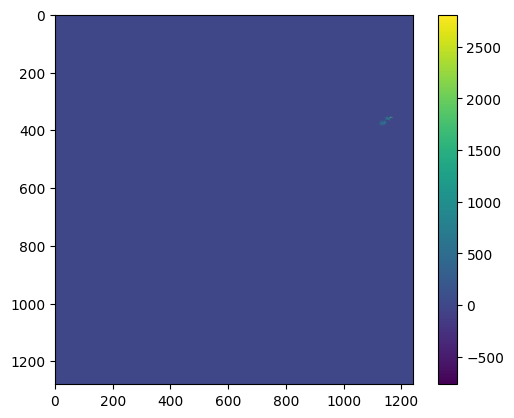

In [131]:
fig, axs = plt.subplots()
img = axs.imshow(np.squeeze(plume.ch4_mf.data)*plume_mask)
_ = fig.colorbar(img)

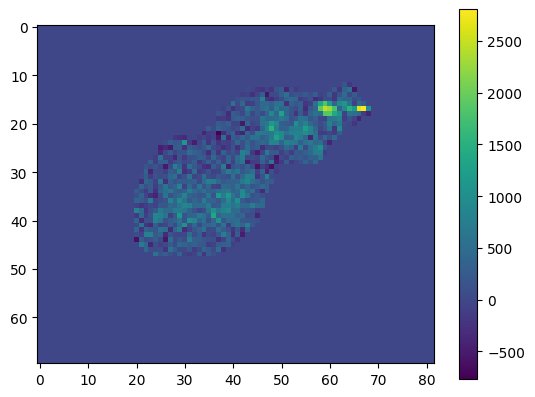

In [132]:
line_slice = slice(340,410)
sample_slice = slice(1100,-60)
fig, axs = plt.subplots()
img = axs.imshow((np.squeeze(plume.ch4_mf.data)*plume_mask)[line_slice,sample_slice])
_ = fig.colorbar(img)

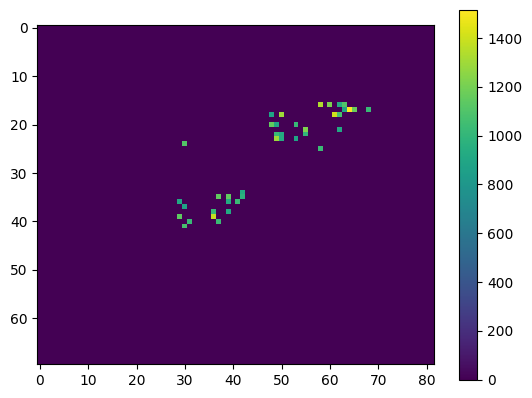

In [133]:
fig, axs = plt.subplots()
img = axs.imshow((np.squeeze(plume.ch4_mf.data)*target_pixel_mask)[line_slice,sample_slice])
_ = fig.colorbar(img)

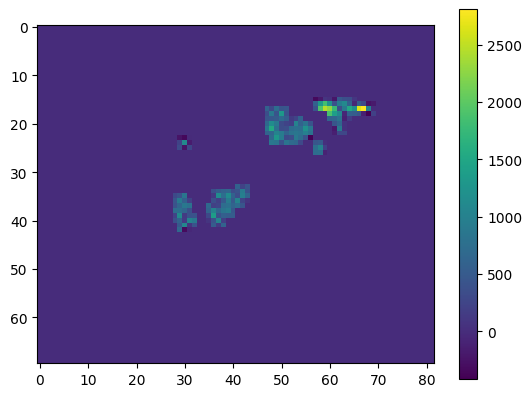

In [134]:
fig, axs = plt.subplots()
img = axs.imshow((np.squeeze(plume.ch4_mf.data)*dilated_target_pixel_mask)[line_slice,sample_slice])
_ = fig.colorbar(img)

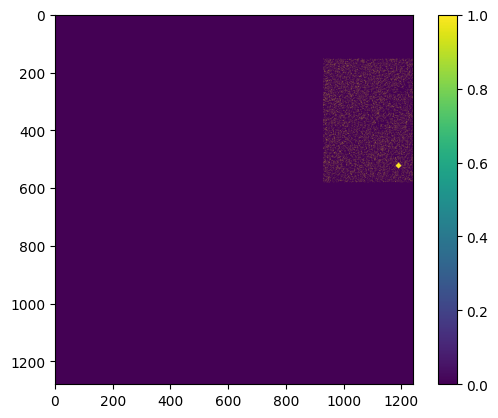

In [135]:
fig, axs = plt.subplots()
img = axs.imshow(background_pixel_mask)
#img = axs.imshow(background_pixel_mask[line_slice,sample_slice])
_ = fig.colorbar(img)

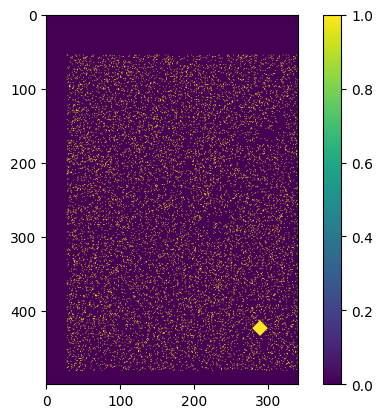

In [136]:
fig, axs = plt.subplots()
img = axs.imshow(background_pixel_mask[100:600,900:-1])
#img = axs.imshow(background_pixel_mask[line_slice,sample_slice])
_ = fig.colorbar(img)

In [137]:
print(f'dilated_target_pixel_mask nonzeros: {np.count_nonzero(dilated_target_pixel_mask)}')
print(f'background_pixel_mask nonzeros: {np.count_nonzero(background_pixel_mask)}')

dilated_target_pixel_mask nonzeros: 227
background_pixel_mask nonzeros: 11243


In [138]:
print(l1b_radiance.data.shape)
print(l1b_radiance.data[dilated_target_pixel_mask].shape)

(1280, 1242, 285)
(227, 285)


In [139]:
#
# "optimal" target and background pixel pairing based on non-ch4 wavelengths:
#

In [140]:
dilated_target_pixel_mask_indices = np.where(dilated_target_pixel_mask)
background_pixel_mask_indices = np.where(background_pixel_mask)

In [141]:
wl = np.array(l1b_radiance.hdr['wavelength'],dtype=float)
ch4_rngs = np.array(cfg['ch4_absorption_ranges'])
ch4_wl_indices = []
# accommodate any number of ch4_rngs range pairs:
for i in range(ch4_rngs.shape[0]):
    ch4_wl_indices.extend(list(np.where((wl >= ch4_rngs[i,0]) & (wl <= ch4_rngs[i,1]))[0]))
# and, just to be sure, make sure none of the indices are repeated, and 
# sort for convenience:
ch4_wl_indices = list(set(ch4_wl_indices))
ch4_wl_indices.sort()
non_ch4_wl_indices = list(set(range(len(wl))).difference(set(ch4_wl_indices)))
target_non_ch4_spectra = l1b_radiance.data[dilated_target_pixel_mask][:,non_ch4_wl_indices]
background_non_ch4_spectra = l1b_radiance.data[background_pixel_mask][:,non_ch4_wl_indices]

In [142]:
# L1-normalized Euclidian distance spectral similarity matrix (target pixel rows x background pixel columns):
similarity_matrix = cdist( target_non_ch4_spectra, background_non_ch4_spectra, 'euclidean')

In [143]:
similarity_matrix.shape

(227, 11243)

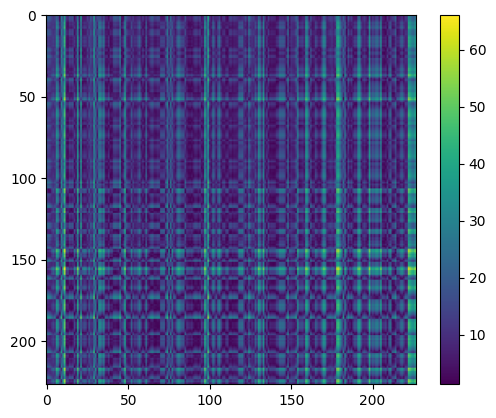

In [144]:
# plot a square segment of the similarity matrix (given the shape, view of entire matrix is not very illustrative):
fig, axs = plt.subplots()
img = axs.imshow(similarity_matrix[:227,-227:])
_ = fig.colorbar(img)

In [145]:
# use optimal assignment to determine non-repeated index pairs (for each target pixel, corresponding "best fit" background pixel,
# no background pixel used more than once):
target_indices, background_indices = linear_sum_assignment(similarity_matrix)

In [146]:
# gather indices, metrics in DataFrame for subsequent operations, analysis:
similarity_results_df = pd.DataFrame(columns=[
    'similarity_matrix_target_index',
    'similarity_matrix_background_index',
    'similarity_matrix_coefficient',
    'target_pixel_indices',
    'background_pixel_indices',
    'target_mf',
    'background_mf',
    'target_mean_radiance',
    'background_mean_radiance'])
for tgt_idx,bg_idx in zip(target_indices, background_indices):
    similarity_results_df.loc[tgt_idx] = [
        tgt_idx,
        bg_idx,
        similarity_matrix[tgt_idx,bg_idx],
        (dilated_target_pixel_mask_indices[0][tgt_idx],dilated_target_pixel_mask_indices[1][tgt_idx]),
        (background_pixel_mask_indices[0][bg_idx],background_pixel_mask_indices[1][bg_idx]),
        np.squeeze(plume.ch4_mf.data[(dilated_target_pixel_mask_indices[0][tgt_idx],dilated_target_pixel_mask_indices[1][tgt_idx])]),
        np.squeeze(plume.ch4_mf.data[(background_pixel_mask_indices[0][tgt_idx],background_pixel_mask_indices[1][tgt_idx])]),
        np.mean(l1b_radiance.data[(dilated_target_pixel_mask_indices[0][tgt_idx],dilated_target_pixel_mask_indices[1][tgt_idx]),:]),
        np.mean(l1b_radiance.data[(background_pixel_mask_indices[0][tgt_idx],background_pixel_mask_indices[1][tgt_idx]),:]),
    ]

In [147]:
similarity_results_df

,similarity_matrix_target_index,similarity_matrix_background_index,similarity_matrix_coefficient,target_pixel_indices,background_pixel_indices,target_mf,background_mf,target_mean_radiance,background_mean_radiance
0,0,4927,0.672334,"(355, 1157)","(343, 1156)",-331.0264,-27.493105,2.468878,2.562405
1,1,5232,0.575079,"(355, 1158)","(354, 1159)",-190.46614,23.066006,2.469854,2.564194
2,2,1405,0.458759,"(355, 1159)","(206, 1219)",85.5982,-13.802275,2.470955,2.551566
3,3,8299,0.589859,"(355, 1160)","(474, 1104)",51.533077,-6.2253356,2.472339,2.541377
4,4,3873,0.721850,"(355, 1161)","(299, 1193)",-224.64949,0.72041357,2.480322,2.541100
...,...,...,...,...,...,...,...,...,...
222,222,5693,0.582115,"(381, 1137)","(373, 1100)",140.38458,9.988198,2.398529,2.467106
223,223,674,0.498936,"(381, 1138)","(179, 1163)",614.6413,-24.705061,2.403958,2.482454
224,224,3095,1.057822,"(382, 1129)","(271, 1218)",679.99506,6.369723,2.396967,2.468343
225,225,5089,1.184452,"(382, 1130)","(349, 1126)",-314.3956,-2.6329682,2.395144,2.461488


In [148]:
# similarity_results_df.to_csv('similarity_matrix_results_df.csv')

In [149]:
# to account for scene inhomogeneity, consider only a defined percentage of pairs having the lowest (i.e., "best") similarity scores:
sorted_similarity_results_df = similarity_results_df.sort_values(by='similarity_matrix_coefficient')

In [150]:
sorted_similarity_results_df

,similarity_matrix_target_index,similarity_matrix_background_index,similarity_matrix_coefficient,target_pixel_indices,background_pixel_indices,target_mf,background_mf,target_mean_radiance,background_mean_radiance
10,10,4275,0.333644,"(356, 1158)","(315, 1154)",1334.2969,24.995066,2.470276,2.474648
189,189,5948,0.339457,"(378, 1130)","(383, 1130)",645.14545,-4.249424,2.413081,2.462525
103,103,5534,0.364882,"(362, 1156)","(366, 1161)",795.99225,-11.841201,2.456311,2.495055
112,112,3516,0.438505,"(363, 1150)","(287, 1134)",937.54504,-16.872187,2.456971,2.437419
78,78,5012,0.444204,"(360, 1161)","(346, 1164)",431.04642,-18.646654,2.471170,2.448366
...,...,...,...,...,...,...,...,...,...
52,52,7085,1.315548,"(358, 1167)","(428, 1190)",-125.9002,-10.6460085,2.466350,2.475583
51,51,5456,1.342054,"(358, 1166)","(363, 1175)",441.24646,-6.035021,2.468001,2.476624
36,36,137,1.347148,"(357, 1166)","(159, 1135)",2668.7202,-10.366409,2.467802,2.406084
108,108,10641,1.392191,"(363, 1130)","(556, 1122)",-340.5259,23.22097,2.454277,2.475707


In [151]:
sorted_similarity_results_df = sorted_similarity_results_df[:int(len(sorted_similarity_results_df)*cfg['SPECTRAL_SIMILARITY_FRACTION_RETAINED'])]

In [152]:
sorted_similarity_results_df

,similarity_matrix_target_index,similarity_matrix_background_index,similarity_matrix_coefficient,target_pixel_indices,background_pixel_indices,target_mf,background_mf,target_mean_radiance,background_mean_radiance
10,10,4275,0.333644,"(356, 1158)","(315, 1154)",1334.2969,24.995066,2.470276,2.474648
189,189,5948,0.339457,"(378, 1130)","(383, 1130)",645.14545,-4.249424,2.413081,2.462525
103,103,5534,0.364882,"(362, 1156)","(366, 1161)",795.99225,-11.841201,2.456311,2.495055
112,112,3516,0.438505,"(363, 1150)","(287, 1134)",937.54504,-16.872187,2.456971,2.437419
78,78,5012,0.444204,"(360, 1161)","(346, 1164)",431.04642,-18.646654,2.471170,2.448366
...,...,...,...,...,...,...,...,...,...
127,127,1189,0.678057,"(364, 1153)","(198, 1139)",660.1742,-28.697865,2.439216,2.501776
216,216,6327,0.679252,"(380, 1138)","(399, 1160)",214.68285,5.685379,2.403810,2.440444
77,77,3868,0.680107,"(360, 1156)","(299, 1104)",427.2954,22.092463,2.455124,2.451522
183,183,5811,0.680373,"(377, 1139)","(377, 1099)",783.4731,10.3293495,2.433877,2.434781


In [153]:
# target pixel matched filter mean:
sorted_similarity_results_df['target_mf'].mean()

np.float64(538.7273230088496)

In [154]:
# target pixel mean radiance:
sorted_similarity_results_df['target_mean_radiance'].mean()

np.float32(2.4481719)

In [155]:
# background pixel matched filter mean:
sorted_similarity_results_df['background_mf'].mean()

np.float64(-0.18078209868574566)

In [156]:
# background pixel mean radiance:
sorted_similarity_results_df['background_mean_radiance'].mean()

np.float32(2.476158)

In [157]:
# target-to-background radiance ratio:
sorted_similarity_results_df['target_mean_radiance'].mean()/sorted_similarity_results_df['background_mean_radiance'].mean()

np.float32(0.98869777)

In [158]:
target_radiances = l1b_radiance.data[
    [index[0] for index in sorted_similarity_results_df['target_pixel_indices']],   # line indices
    [index[1] for index in sorted_similarity_results_df['target_pixel_indices']],   # sample indices
    :]

In [159]:
background_radiances = l1b_radiance.data[
    [index[0] for index in sorted_similarity_results_df['background_pixel_indices']],   # line indices
    [index[1] for index in sorted_similarity_results_df['background_pixel_indices']],   # sample indices
    :]

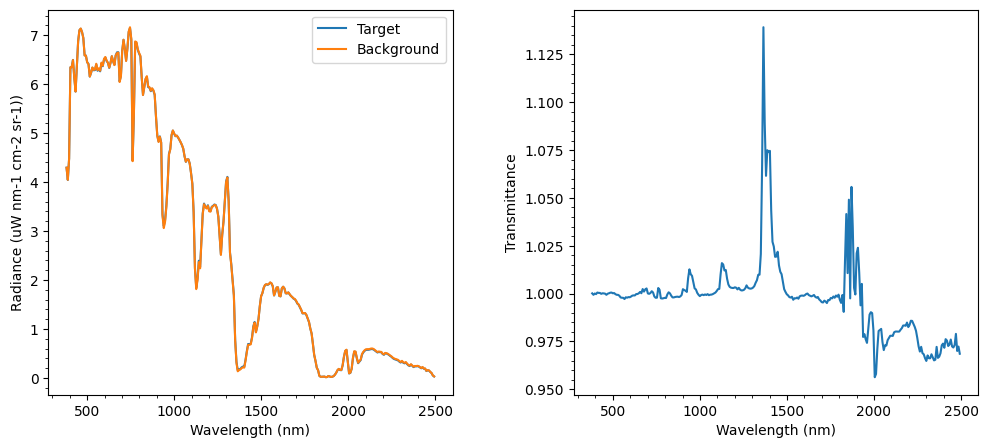

In [160]:
fig, axs = plt.subplots(1,2,figsize=(12,5))
axs[0].plot(wl,np.mean(target_radiances,axis=0),label='Target')
axs[0].plot(wl,np.mean(background_radiances,axis=0),label='Background')
axs[0].minorticks_on()
axs[0].set_xlabel('Wavelength (nm)')
axs[0].set_ylabel('Radiance (uW nm-1 cm-2 sr-1))')
axs[0].legend()
axs[0].minorticks_on()
axs[1].plot(wl,np.mean(target_radiances,axis=0)/np.mean(background_radiances,axis=0))
axs[1].minorticks_on()
axs[1].set_xlabel('Wavelength (nm)')
axs[1].set_ylabel('Transmittance')
plt.subplots_adjust(wspace=0.3,hspace=0.3)

In [161]:
# ch4 wavelength indices for model fitting:
ch4_fitting_rngs = np.array(cfg['ch4_fitting_absorption_ranges'])
ch4_fitting_wl_indices = []
# accommodate any number of ch4_fitting_rngs range pairs:
for i in range(ch4_fitting_rngs.shape[0]):
    ch4_fitting_wl_indices.extend(list(np.where((wl >= ch4_fitting_rngs[i,0]) & (wl <= ch4_fitting_rngs[i,1]))[0]))
# and, just to be sure, make sure none of the indices are repeated, and 
# sort for convenience:
ch4_fitting_wl_indices = list(set(ch4_fitting_wl_indices))
ch4_fitting_wl_indices.sort()

In [162]:
print(ch4_fitting_wl_indices)

[np.int64(231), np.int64(232), np.int64(233), np.int64(234), np.int64(235), np.int64(236), np.int64(237), np.int64(238), np.int64(239), np.int64(240), np.int64(241), np.int64(242), np.int64(243), np.int64(244), np.int64(245), np.int64(246), np.int64(247), np.int64(248), np.int64(249), np.int64(250), np.int64(251), np.int64(252), np.int64(253), np.int64(254), np.int64(255), np.int64(256), np.int64(257), np.int64(258), np.int64(259), np.int64(260), np.int64(261), np.int64(262), np.int64(263), np.int64(264), np.int64(265), np.int64(266), np.int64(267), np.int64(268), np.int64(269), np.int64(270), np.int64(271), np.int64(272), np.int64(273), np.int64(274), np.int64(275), np.int64(276)]


In [163]:
print(wl[ch4_fitting_wl_indices])

[2100.7691374 2108.1821846 2115.5942712 2123.0063974 2130.4175635
 2137.8287695 2145.2390158 2152.6483026 2160.05763   2167.4669983
 2174.8754077 2182.2828584 2189.6903506 2197.0968845 2204.5034603
 2211.9090783 2219.3147387 2226.7194416 2234.1231873 2241.5269759
 2248.9298078 2256.3326831 2263.734602  2271.1365648 2278.5375716
 2285.9386227 2293.3387182 2300.7378584 2308.1360436 2315.5342738
 2322.9325493 2330.3298704 2337.7262372 2345.12165   2352.5171089
 2359.9126142 2367.3071661 2374.7007647 2382.0934104 2389.4861034
 2396.8778437 2404.2696317 2411.6604675 2419.0513515 2426.4402837
 2433.8302643]


In [164]:
# save data for subsequent demos:
with open('demo_plume_pixel_pairing_target_radiances.npy','wb') as f:
    np.save(f,target_radiances)
with open('demo_plume_pixel_pairing_background_radiances.npy','wb') as f:
    np.save(f,background_radiances)